# 04 — Feature Extraction
For every BLS candidate we extract numerical features that the classifier will use.
These features capture the shape, symmetry, and statistics of each transit signal.

## 1. Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
from astropy.timeseries import BoxLeastSquares
import astropy.units as u
from tqdm import tqdm
import os, glob, warnings
warnings.filterwarnings('ignore')
print('Imports OK!')

Imports OK!


## 2. Configuration

In [20]:
PROCESSED_DIR = '../data/processed/'
BLS_RESULTS   = '../outputs/bls_all_results.csv'
OUTPUT_FILE   = '../outputs/features.csv'

# Load BLS results
bls_df = pd.read_csv(BLS_RESULTS)

# ── FIX: strip the .0 from TIC IDs ──
bls_df['tic_id'] = bls_df['tic_id'].astype(str).str.replace('.0', '', regex=False)

print(f'Loaded {len(bls_df)} BLS results')
print(bls_df['tic_id'].values)   # Should show clean IDs without .0

Loaded 15 BLS results
['149603524' '229742722' '237201858' '260647166' '261136641' '261136679'
 '261136765' '261139167' '261155555' '261203535' '271893367' '279741379'
 '350618622' '441075486' '55525572']


## 3. Feature Extraction Functions
We extract 3 groups of features:
- **BLS features** — period, depth, duration, SNR (already computed)
- **Shape features** — odd/even depth, secondary eclipse, skewness
- **Statistical features** — scatter, flux range, outlier fraction

In [21]:
def phase_fold(time, flux, period, t0):
    """Phase fold a light curve and center transit at phase=0."""
    phase = ((time - t0) % period) / period
    phase[phase > 0.5] -= 1.0
    sort_idx = np.argsort(phase)
    return phase[sort_idx], flux[sort_idx]


def get_transit_mask(phase, duration, period):
    """Boolean mask: True inside transit window."""
    half = (duration / period) / 2.0
    return np.abs(phase) < half


def odd_even_depth(time, flux, period, t0, duration):
    """
    Compute depth of odd vs even transits separately.
    Eclipsing binaries show alternating deep/shallow transits.
    Returns (odd_depth, even_depth, difference).
    """
    half = duration / 2.0
    transit_times = []
    n_transits = int((time[-1] - time[0]) / period)

    for i in range(n_transits + 1):
        tc = t0 + i * period
        mask = np.abs(time - tc) < half
        if mask.sum() > 3:
            transit_times.append((i, 1.0 - np.median(flux[mask])))

    if len(transit_times) < 2:
        return 0.0, 0.0, 0.0

    odd_depths  = [d for i, d in transit_times if i % 2 == 1]
    even_depths = [d for i, d in transit_times if i % 2 == 0]

    odd_mean  = np.mean(odd_depths)  if odd_depths  else 0.0
    even_mean = np.mean(even_depths) if even_depths else 0.0
    diff      = abs(odd_mean - even_mean)

    return odd_mean, even_mean, diff


def secondary_eclipse_depth(phase, flux, duration, period):
    """
    Check for secondary eclipse at phase=0.5 (opposite side of orbit).
    Real planets have NO secondary eclipse. EBs do.
    """
    # Shift phase to check at 0.5
    sec_phase = phase.copy()
    sec_phase[sec_phase < 0] += 1.0
    half = (duration / period) / 2.0
    sec_mask = np.abs(sec_phase - 0.5) < half

    if sec_mask.sum() < 3:
        return 0.0

    out_mask    = ~get_transit_mask(phase, duration, period) & (np.abs(sec_phase - 0.5) > half * 2)
    baseline    = np.median(flux[out_mask]) if out_mask.sum() > 3 else 1.0
    sec_depth   = baseline - np.median(flux[sec_mask])
    return max(sec_depth, 0.0)


def extract_features(tic_id, time, flux, bls_row):
    """
    Extract all features for one star.
    Returns a dict of features.
    """
    period   = bls_row['period_days']
    duration = bls_row['duration_days']
    depth    = bls_row['depth_ppm'] / 1e6
    t0       = bls_row['transit_time']
    snr      = bls_row['snr']

    # Phase fold
    phase, flux_folded = phase_fold(time, flux, period, t0)
    in_transit  = get_transit_mask(phase, duration, period)
    out_transit = ~in_transit

    # --- BLS features (direct) ---
    feat = {
        'tic_id'            : tic_id,
        'period_days'       : period,
        'duration_days'     : duration,
        'duration_hours'    : duration * 24,
        'depth_ppm'         : bls_row['depth_ppm'],
        'snr'               : snr,
        'bls_power'         : bls_row['bls_power'],
    }

    # --- Shape features ---
    if in_transit.sum() > 3 and out_transit.sum() > 3:
        flux_in  = flux_folded[in_transit]
        flux_out = flux_folded[out_transit]

        feat['transit_depth_measured'] = float(np.median(flux_out) - np.median(flux_in))
        feat['flux_in_scatter']        = float(np.std(flux_in))
        feat['flux_out_scatter']       = float(np.std(flux_out))
        feat['in_out_scatter_ratio']   = float(np.std(flux_in) / (np.std(flux_out) + 1e-10))

        # Skewness of transit shape (V-shape vs flat-bottom)
        feat['transit_skewness']       = float(stats.skew(flux_in)) if len(flux_in) > 3 else 0.0
        feat['transit_kurtosis']       = float(stats.kurtosis(flux_in)) if len(flux_in) > 3 else 0.0
    else:
        feat['transit_depth_measured'] = 0.0
        feat['flux_in_scatter']        = 0.0
        feat['flux_out_scatter']       = 0.0
        feat['in_out_scatter_ratio']   = 0.0
        feat['transit_skewness']       = 0.0
        feat['transit_kurtosis']       = 0.0

    # --- Odd/Even depth (key EB indicator) ---
    odd_d, even_d, oe_diff = odd_even_depth(time, flux, period, t0, duration)
    feat['odd_depth']       = odd_d
    feat['even_depth']      = even_d
    feat['odd_even_diff']   = oe_diff

    # --- Secondary eclipse (key EB indicator) ---
    feat['secondary_depth'] = secondary_eclipse_depth(phase, flux_folded, duration, period)

    # --- Statistical features ---
    feat['flux_mean']       = float(np.mean(flux))
    feat['flux_std']        = float(np.std(flux))
    feat['flux_range']      = float(np.max(flux) - np.min(flux))
    feat['outlier_frac']    = float(np.sum(np.abs(flux - np.mean(flux)) > 3 * np.std(flux)) / len(flux))

    # --- Ratio features ---
    feat['depth_over_std']  = float(depth / (np.std(flux) + 1e-10))
    feat['period_over_dur'] = float(period / (duration + 1e-10))

    return feat

print('Feature functions defined!')

Feature functions defined!


## 4. Extract Features for ALL BLS Results

In [22]:
# At the top of the loop, force clean ID
tic_id   = str(bls_row['tic_id']).replace('.0', '')
csv_path = os.path.join(PROCESSED_DIR, f'TIC_{tic_id}.csv')
all_features = []

for _, bls_row in tqdm(bls_df.iterrows(), total=len(bls_df), desc='Extracting features'):
    tic_id   = str(bls_row['tic_id'])
    csv_path = os.path.join(PROCESSED_DIR, f'TIC_{tic_id}.csv')

    if not os.path.exists(csv_path):
        print(f'❌ Missing: {csv_path}')
        continue

    try:
        df   = pd.read_csv(csv_path)
        time = df['time'].values
        flux = df['flux'].values

        mask = np.isfinite(time) & np.isfinite(flux)
        time = time[mask]
        flux = flux[mask]

        if len(time) < 50:
            print(f'TIC {tic_id} ⚠️  too few points ({len(time)}), skipping')
            continue

        feat = extract_features(tic_id, time, flux, bls_row)
        all_features.append(feat)
        print(f'TIC {tic_id} ✅  features extracted ({len(feat)} columns)')

    except Exception as e:
        print(f'TIC {tic_id} ❌  ERROR: {e}')
        import traceback
        traceback.print_exc()   # ← This shows FULL error details

# Save regardless of how many we got
features_df = pd.DataFrame(all_features)
print(f'\nTotal features extracted: {len(features_df)}')

if len(features_df) > 0:
    features_df.to_csv(OUTPUT_FILE, index=False)
    print(features_df[['tic_id','snr','depth_ppm','odd_even_diff']].to_string())
else:
    print('❌ Still empty — paste the full traceback above')

Extracting features:  47%|████▋     | 7/15 [00:00<00:00, 68.86it/s]

TIC 149603524 ✅  features extracted (23 columns)
TIC 229742722 ✅  features extracted (23 columns)
TIC 237201858 ✅  features extracted (23 columns)
TIC 260647166 ✅  features extracted (23 columns)
TIC 261136641 ✅  features extracted (23 columns)
TIC 261136679 ✅  features extracted (23 columns)
TIC 261136765 ✅  features extracted (23 columns)
TIC 261139167 ✅  features extracted (23 columns)
TIC 261155555 ✅  features extracted (23 columns)


Extracting features: 100%|██████████| 15/15 [00:00<00:00, 85.10it/s]

TIC 261203535 ✅  features extracted (23 columns)
TIC 271893367 ✅  features extracted (23 columns)
TIC 279741379 ✅  features extracted (23 columns)
TIC 350618622 ✅  features extracted (23 columns)
TIC 441075486 ✅  features extracted (23 columns)
TIC 55525572 ✅  features extracted (23 columns)

Total features extracted: 15
       tic_id           snr     depth_ppm  odd_even_diff
0   149603524      0.013233  3.120597e+03       0.003520
1   229742722      0.005397  6.921242e+02       0.000240
2   237201858      0.005233  4.363268e+02       0.000210
3   260647166      0.006059  4.713732e+02       0.000453
4   261136641      0.003167  4.727299e+02       0.000059
5   261136679      0.003590  1.791145e+02       0.000034
6   261136765      0.008037  1.186442e+03       0.000334
7   261139167      0.005055  2.132918e+02       0.000133
8   261155555      0.060653  2.742405e+03       0.000464
9   261203535  23768.341495  5.317702e+09     309.915551
10  271893367      0.004899  7.533936e+02       0.

## 5. Save Features

In [23]:
features_df.to_csv(OUTPUT_FILE, index=False)
print(f'Saved features to {OUTPUT_FILE}')
print(f'Shape: {features_df.shape}')
print(f'\nFeature columns:')
for col in features_df.columns:
    print(f'  {col}')

Saved features to ../outputs/features.csv
Shape: (15, 23)

Feature columns:
  tic_id
  period_days
  duration_days
  duration_hours
  depth_ppm
  snr
  bls_power
  transit_depth_measured
  flux_in_scatter
  flux_out_scatter
  in_out_scatter_ratio
  transit_skewness
  transit_kurtosis
  odd_depth
  even_depth
  odd_even_diff
  secondary_depth
  flux_mean
  flux_std
  flux_range
  outlier_frac
  depth_over_std
  period_over_dur


## 6. Also Extract Features for Labeled Dataset (for training)

In [24]:
LABELED_PROCESSED = '../data/labeled/processed/'
LABELS_CSV        = '../data/labeled/labels.csv'
LABELED_FEAT_OUT  = '../outputs/labeled_features.csv'

if not os.path.exists(LABELS_CSV):
    print('No labeled dataset found — skipping. This is OK for now.')
else:
    labels_df     = pd.read_csv(LABELS_CSV)
    labeled_feats = []

    for _, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc='Labeled features'):
        tic_id = str(row['tic_id'])
        label  = row['label']

        # Find matching processed CSV
        pattern = glob.glob(os.path.join(LABELED_PROCESSED, f'TIC_{tic_id}*.csv'))
        if not pattern:
            print(f'Missing processed file for TIC {tic_id}')
            continue

        try:
            df   = pd.read_csv(pattern[0])
            time = df['time'].values
            flux = df['flux'].values
            mask = np.isfinite(time) & np.isfinite(flux)
            time = time[mask]
            flux = flux[mask]

            # Run BLS first to get parameters
            from astropy.timeseries import BoxLeastSquares
            bls    = BoxLeastSquares(time * u.day, flux)
            durations = np.linspace(0.01, 0.3, 20) * u.day
            pgram  = bls.autopower(durations,
                                   minimum_period=1.0*u.day,
                                   maximum_period=13.0*u.day)
            best_i = np.argmax(pgram.power)
            bls_stats = bls.compute_stats(pgram.period[best_i],
                                          pgram.duration[best_i],
                                          pgram.transit_time[best_i])
            depth     = float(bls_stats['depth'][0])
            depth_err = float(bls_stats['depth'][1])

            bls_row = pd.Series({
                'period_days'   : float(pgram.period[best_i].value),
                'duration_days' : float(pgram.duration[best_i].value),
                'depth_ppm'     : depth * 1e6,
                'snr'           : depth / depth_err if depth_err > 0 else 0,
                'bls_power'     : float(pgram.power[best_i]),
                'transit_time'  : float(pgram.transit_time[best_i].value)
            })

            feat        = extract_features(tic_id, time, flux, bls_row)
            feat['label'] = label
            labeled_feats.append(feat)
            print(f'TIC {tic_id} ({label}) ✅')

        except Exception as e:
            print(f'TIC {tic_id} ❌ {e}')

    labeled_feat_df = pd.DataFrame(labeled_feats)
    labeled_feat_df.to_csv(LABELED_FEAT_OUT, index=False)
    print(f'\nSaved labeled features → {LABELED_FEAT_OUT}')
    print(labeled_feat_df[['tic_id','label','snr','odd_even_diff','secondary_depth']])

Labeled features:   7%|▋         | 1/15 [00:14<03:27, 14.80s/it]

TIC 261136679 (planet) ✅


Labeled features:  13%|█▎        | 2/15 [00:29<03:12, 14.83s/it]

TIC 238004786 (planet) ✅


Labeled features:  20%|██        | 3/15 [00:42<02:49, 14.11s/it]

...

TIC 219016883 (eclipsing_binary) ✅


Labeled features:  93%|█████████▎| 14/15 [03:11<00:14, 14.48s/it]

TIC 284925600 (eclipsing_binary) ✅


Labeled features: 100%|██████████| 15/15 [03:19<00:00, 13.30s/it]

TIC 120896927 (eclipsing_binary) ✅

Saved labeled features → ../outputs/labeled_features.csv
       tic_id             label       snr  odd_even_diff  secondary_depth
0   261136679            planet  0.003590       0.000034         0.000000
1   238004786            planet  0.008437       0.000074         0.000000
2   307210830            planet  0.019661       0.000158         0.000000
3   394137592            planet  0.002497       0.000127         0.000000
4   460205581            planet  0.021653       0.002439         0.000000
5    25155310            planet  0.038753       0.000672         0.000000
6    29857954            planet  0.003431       0.000220         0.000000
7    55525572            planet  0.002986       0.000004         0.000000
8   259377017            planet  0.023027       0.002382         0.000160
9   149603524            planet  0.013233       0.003520         0.000000
10  229804573  eclipsing_binary  2.614452       0.009515         0.052711
11  142087638  ecli

## 7. Feature Visualization

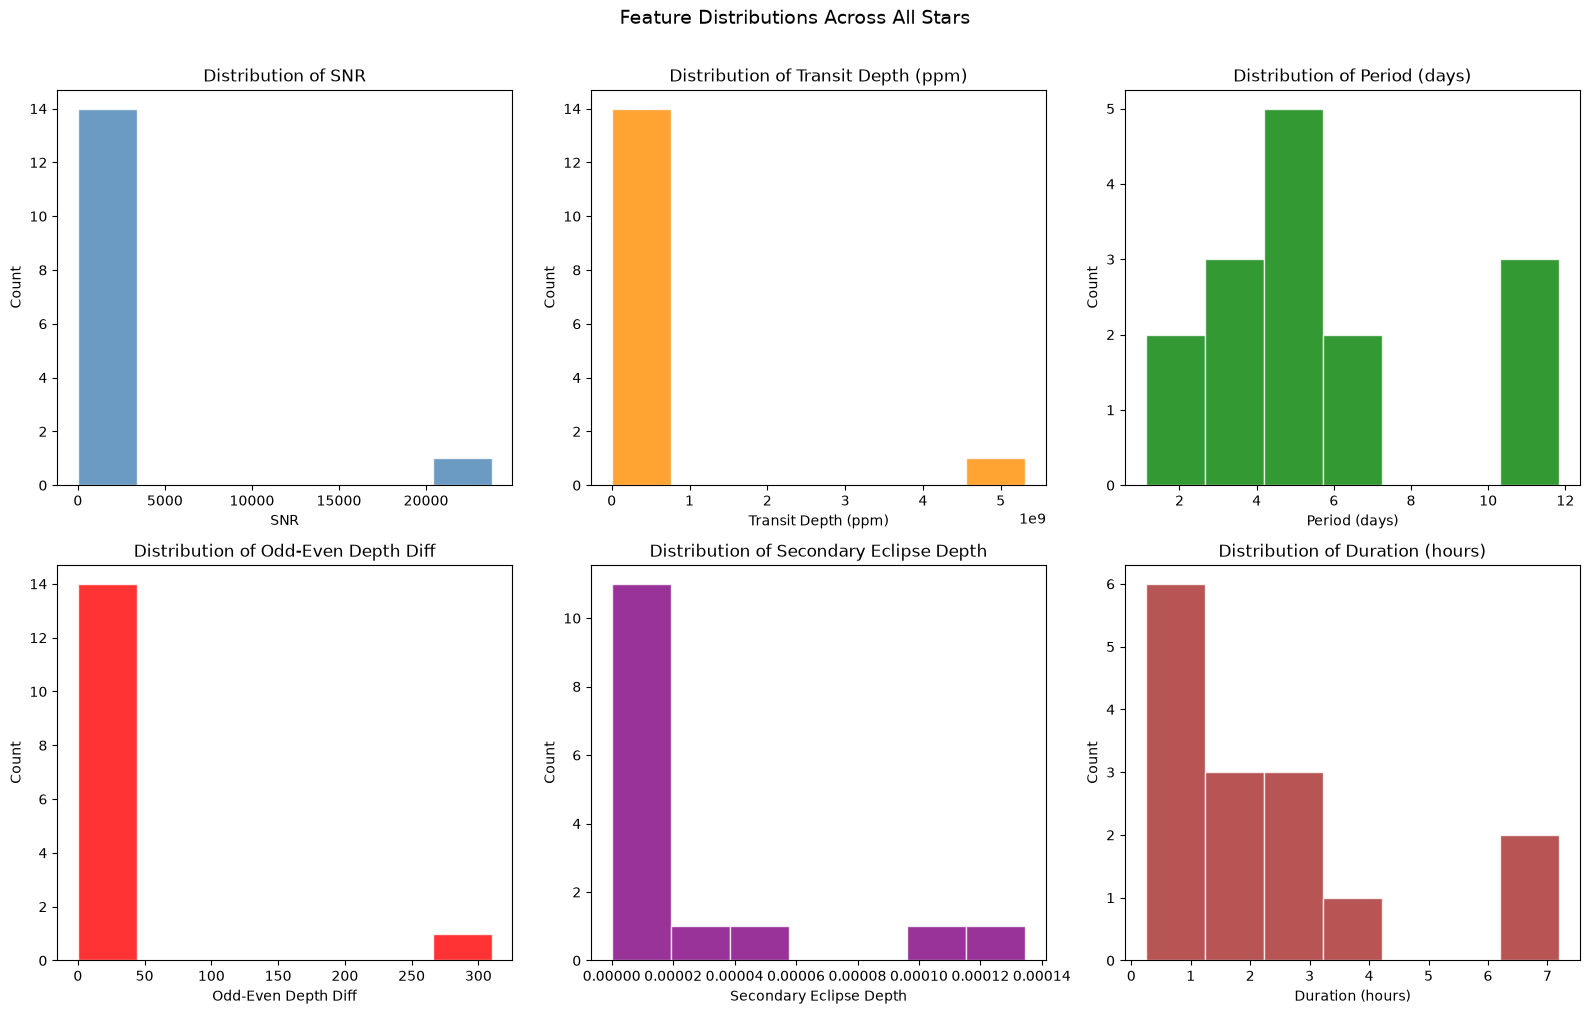

Feature distribution plot saved!


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_features = [
    ('snr',             'SNR',                  'steelblue'),
    ('depth_ppm',       'Transit Depth (ppm)',   'darkorange'),
    ('period_days',     'Period (days)',          'green'),
    ('odd_even_diff',   'Odd-Even Depth Diff',   'red'),
    ('secondary_depth', 'Secondary Eclipse Depth','purple'),
    ('duration_hours',  'Duration (hours)',       'brown'),
]

for ax, (col, label, color) in zip(axes, plot_features):
    if col in features_df.columns:
        ax.hist(features_df[col], bins=max(5, len(features_df)//2),
                color=color, edgecolor='white', alpha=0.8)
        ax.set_xlabel(label)
        ax.set_ylabel('Count')
        ax.set_title(f'Distribution of {label}')

plt.suptitle('Feature Distributions Across All Stars', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/plots/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature distribution plot saved!')

---
## ✅ Done!
**What was saved:**
- `outputs/features.csv` — features for all science stars
- `outputs/labeled_features.csv` — features for labeled training data (if available)
- `outputs/plots/feature_distributions.png` — feature histograms

**Key features explained:**
- `odd_even_diff` → High = likely Eclipsing Binary
- `secondary_depth` → High = likely Eclipsing Binary  
- `snr` → Higher = more confident detection
- `depth_ppm` → Planet transits typically < 10,000 ppm

**Next Step → Run `05_model_training.ipynb`**